In [6]:
import tensorflow as tf


In [7]:
print(tf.__version__)

2.20.0


In [9]:
import zipfile

with zipfile.ZipFile('/content/fruit-data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

✅ STEP 1: Load Dataset in Colab

In [10]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/fruit-data",
    image_size=(128, 128),
    batch_size=32
)

print("Classes:", train_data.class_names)

Found 40 files belonging to 2 classes.
Classes: ['bad', 'good']


✅ STEP 2: Normalize Data

In [11]:
train_data = train_data.map(lambda x, y: (x/255.0, y))

✅ STEP 3: Build Your Model

In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

✅ STEP 4: Train with Adam (First Run)

In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_adam = model.fit(train_data, epochs=5)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.4500 - loss: 0.8391
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.5000 - loss: 2.2724
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.5500 - loss: 0.6209
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 1.0000 - loss: 0.2631
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.9000 - loss: 0.2426


✅ STEP 5: Train with SGD (Optimization Comparison 🔥)

In [14]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_sgd = model.fit(train_data, epochs=5)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9000 - loss: 0.2307
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.6000 - loss: 1.2096
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 1.0000 - loss: 0.1679
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - accuracy: 0.9750 - loss: 0.1832
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 1.0000 - loss: 0.1184


STEP 6: Compare Results

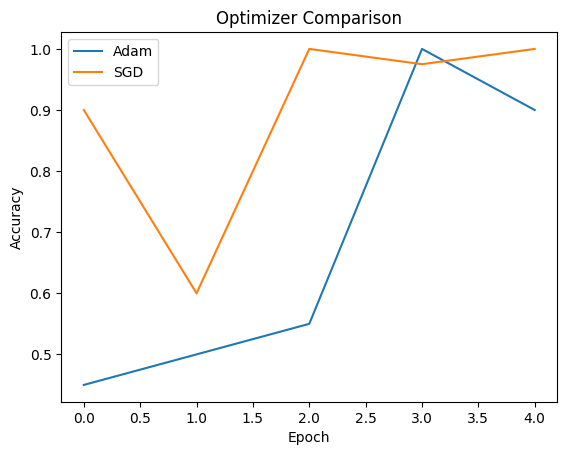

In [15]:
import matplotlib.pyplot as plt

plt.plot(history_adam.history['accuracy'], label='Adam')
plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

I implemented a CNN model and analyzed optimization algorithms (Adam vs SGD) on convergence behavior